In [35]:
# Library/Module imports; pandas, numpy, and matplolib require pip installs, os not
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os as os

In [36]:
"""
Get File Dict: checks directory of folder and saves all the
files into a dictionary/hashmap and returns
"""
def get_file_dict():
    hFDict = {}
    # Making a loopable list based on the relative path folder in the directory 
    directory_path = '../arcticDataexploring/groundheatflux_csv'
    heatFluxCharts = os.listdir(directory_path)

    # Looping over files in user directory and saving DataFrames to a dictionary
    for content in heatFluxCharts:
        hfPath = os.path.join(directory_path, content)
        if os.path.isfile(hfPath):
            hFDict.update({content: pd.read_csv(hfPath)})

    return hFDict

"""
Get Parsed Data: uses parameters to return a dataFrame based on certain attributes
"""
def get_parsed_data(sortbySection, dataArgument, dataInput):
    newParsed = dataInput[dataInput[sortbySection] == dataArgument]
    return newParsed


<Axes: title={'center': 'Organic HD Heatflux in 2017'}, xlabel='doy'>

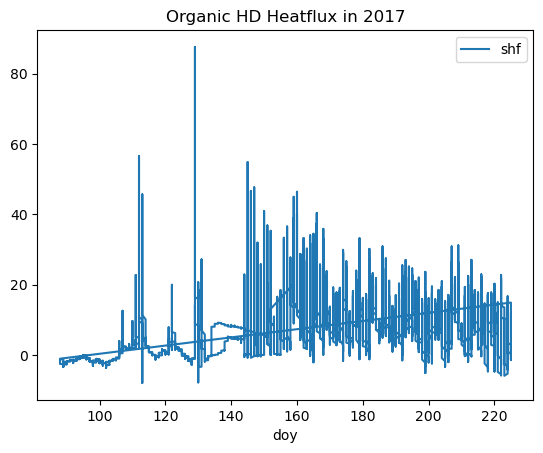

In [37]:
"""
Hardcoded version: removes user input and returns everything
inside/must be changed or re-ran to narrow down lists further
"""

# Parsing masterlist heatflux data by year
fluxDict = get_file_dict()
masterlistHF = fluxDict.get('ground_heatflux (3).csv')


# Heat flux based by years 2016-2017
heatFlux2016 = masterlistHF[masterlistHF['year'] == 2016] # Pandas filtering commands dataframe[dataframe['column you want']]
heatFlux2017 = masterlistHF[masterlistHF['year'] == 2017] # Pandas filtering commands

# Filter new dataframes by site hd/ld for years 2017 
hdHeatFlux2017 = heatFlux2017[heatFlux2017['site'] == 'hd']
ldHeatFlux2017 = heatFlux2017[heatFlux2017['site'] == 'ld']

# This instance, I will be graphing the organic loc of hdHeatFlux2017
organicHd2017 = get_parsed_data('loc', 'organic', hdHeatFlux2017)
filterOrgHd2017 = organicHd2017.drop(columns=['sensorZ', 'year', 'site', 'loc', 'hour'])

filterOrgHd2017.plot(kind = 'line', x='doy', y='shf', title = 'Organic HD Heatflux in 2017')
# Note, due to the graphs use of days, it may be in best interest to get the mean of
    # all doy before plotting







<Axes: title={'center': 'Organic HD Heatflux in 2017'}, xlabel='doy'>

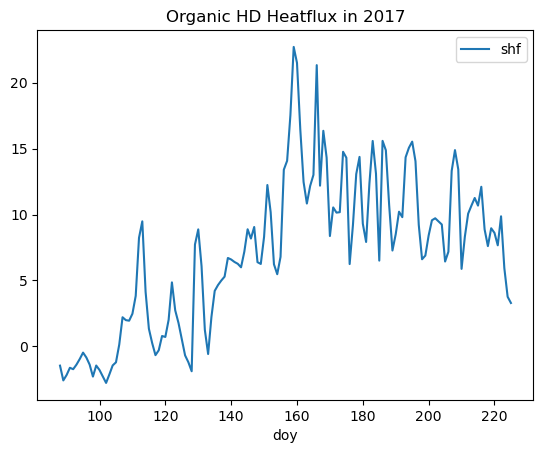

In [38]:
"""
Mean-based graphing, hardcoded version
"""
# Get Mean of Dataset
doy_avg = filterOrgHd2017.groupby('doy')['shf'].mean().reset_index()
doy_avg.plot(kind = 'line', x='doy', y='shf', title = 'Organic HD Heatflux in 2017')



In [39]:
"""
User-Input Specific: formats a While True loop to consistently ask
for user input to change data, view it, or various commands
"""

'\nUser-Input Specific: formats a While True loop to consistently ask\nfor user input to change data, view it, or various commands\n'